In [ ]:
print("Hello God!")

Hello God!


In [ ]:
import numpy as np
import pandas as pd

print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)


NumPy: 2.3.2
Pandas: 2.3.1


In [ ]:
from analyze_src.basic_data_inspection import DataInspecttor, DataTypesInspectionStrategy, SummaryStatisticsInspectionStrategy

In [ ]:
from analyze_src.missing_values_analysis import SimpleMissingValuesAnalysis
from analyze_src.univariate_analysis import UnivariateAnalyzer, NumericalUnivariateAnalysis, CategoricalUnivariateAnalysis
from analyze_src.bivariate_analysis import BivariateAnalyzer, NumericalVsNumericalAnalysis, CategoricalVsNumericalAnalysis
from analyze_src.multivariate_analysis import SimpleMultivariateAnalysis

# Set display options for better readability
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [ ]:
# Load the data
# Assuming you have already extracted the data into the "extracted_data" folder

data_path = "../extracted_data/AmesHousing.csv"
df = pd.read_csv(data_path)

In [ ]:
# Step 1: Basic Data Inspection
# -----------------------------
# Initialize the Data Inspector with a strategy for Data Types Inspection
data_inpector = DataInspecttor(DataTypesInspectionStrategy())
data_inpector.execute_inspection(df)


Data Tyes and Non-null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   object 
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   object 
 7   Alley            198 non-null    object 
 8   Lot Shape        2930 non-null   object 
 9   Land Contour     2930 non-null   object 
 10  Utilities        2930 non-null   object 
 11  Lot Config       2930 non-null   object 
 12  Land Slope       2930 non-null   object 
 13  Neighborhood     2930 non-null   object 
 14  Condition 1      2930 non-null   object 
 15  Condition 2      2930 non-null   object 
 16  Bldg Type        2930 non-nu

In [ ]:
# Switch strategy to Summary Statistics Inspection
data_inpector.set_strategy(SummaryStatisticsInspectionStrategy())
data_inpector.execute_inspection(df)


Summary Statistics (Numerical Features):
            Order           PID  MS SubClass  Lot Frontage       Lot Area  \
count  2930.00000  2.930000e+03  2930.000000   2440.000000    2930.000000   
mean   1465.50000  7.144645e+08    57.387372     69.224590   10147.921843   
std     845.96247  1.887308e+08    42.638025     23.365335    7880.017759   
min       1.00000  5.263011e+08    20.000000     21.000000    1300.000000   
25%     733.25000  5.284770e+08    20.000000     58.000000    7440.250000   
50%    1465.50000  5.354536e+08    50.000000     68.000000    9436.500000   
75%    2197.75000  9.071811e+08    70.000000     80.000000   11555.250000   
max    2930.00000  1.007100e+09   190.000000    313.000000  215245.000000   

       Overall Qual  Overall Cond   Year Built  Year Remod/Add  Mas Vnr Area  \
count   2930.000000   2930.000000  2930.000000     2930.000000   2907.000000   
mean       6.094881      5.563140  1971.356314     1984.266553    101.896801   
std        1.411026     


Missing Values Count by Column:
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

Visualizing Missing Values...


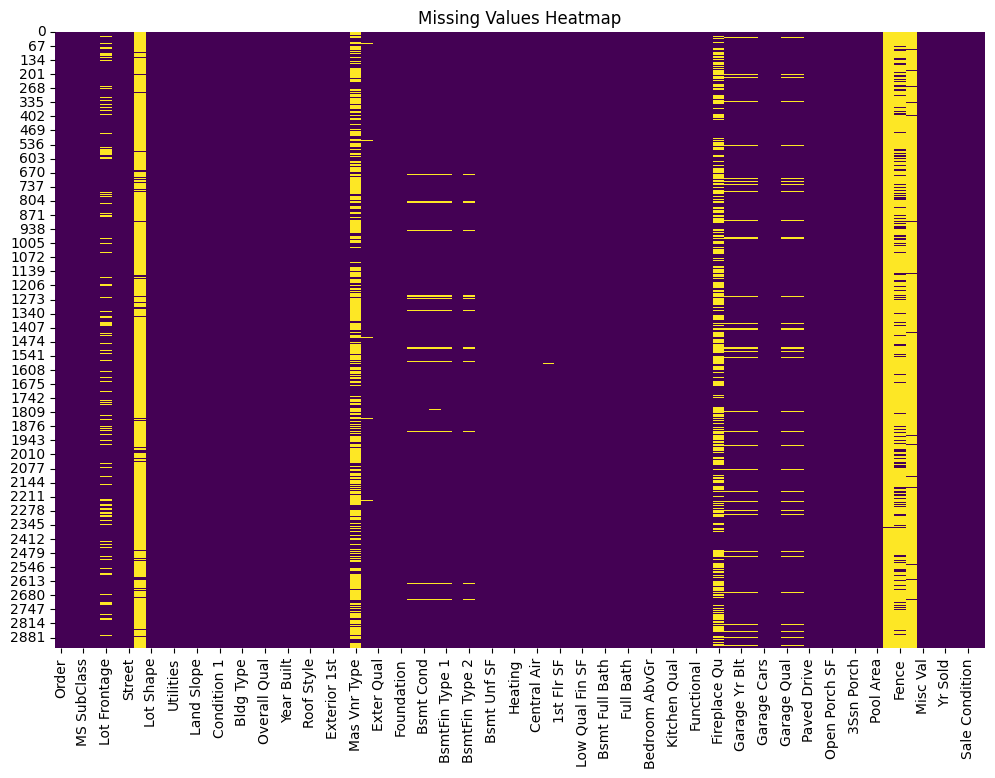

In [ ]:
# Step 2: Missing Values Analysis
#--------------------------------
# Perform Missing Values Analysis
missing_values_analyzer = SimpleMissingValuesAnalysis()
missing_values_analyzer.analyze(df)

## Missing Values Heatmap Insights
1. Colors Represesent Missingness:
* Yellow: Represent missing values. The more yellow you see in a column, the more missing data is present in that particular feature.
* Purple(or dark color): Represents non-missing values. Columns that are mostly purple indicate that most of the data is present for that feature.

2. Identifying columns with Missing Data:
* Look for columns with significant amounts of yellow. These columns have a higher proportion of missing data.
    * For instance, in our heatmap, columns like Lot Frontage, Mas Vnr Type, Mas Vnr Area, Garage Yr Blt, and Pool Area have substantial yellow, indicating that these features have missing values.

3. Understanding the Distribution of Missing Data:
* Randomly Distributed: If the yellow marks are scattered without any noticeable pattern, it suggests that the missing data might be randomly distributed.
* Structured Missingness: If the yellow is clustered in certain rows or columns, it might indicate a non-random pattern of missingness. For example, entire rows or columns missing could suggest a data collection issue or that these features are not applicable in certain cases.

4. Assessing the Severity:
* Columns with more yellow indicate a higher proportion of missing values, which might pose a problem for model building. This could lead to biased or inaccurate models if not handled properly.
       * In our heatmap, some columns have little to no missing values, while others have substantial missingness. Decisions will need to be made on whether to impute, drop, or handle these features differently.


## Insights

1. Data Types and Non-null Counts:
* The dataset contains 2930 entries and 82 columns.
* Data Types: There are 11 columns with float64 data type, 28 columns with int64 data type, and 43 columns with object data type.
     * Numerical Features: These include features like Lot Frontage, Lot Area, Overall Qual, Year Built, etc.
     * Categorical Features: Features like MS Zoning, Street, Neighborhood, Bldg Type, etc., are categorical.

2. Summary Statistics:
* Numerical Features:
    * The target variable SalePrice has a mean of $180,796 with a standard deviation of $79,886, indicating a significant spread in house prices.
    * Overall Qual(quality of the house) ranges from 1 to 10, with a mean of 6.09, showing the relatively high quality on average.
    * Year Built ranges from 1872 to 2010, indicating that the dataset includes both very old and relatively new houses.
    * Lot Area has a wide range, with some extreme outliers(maximum of 215,245 sq. ft.), which might indicate large properties.
    * The distribution of Gr Liv Area(above ground living area) shows a mean of 1499 sq. ft. with a wide range, which could significantly impact SalePrice.

* Categorical Features:
     * Neighborhood has 28 unique values, with Names being the most common, suggesting some neighborhoods might dominate the dataset.
     * MS Zoning is mostly RL(residential low-density), with 7 unique zoning types.
     * Alley has a high frequency of missing values (discussed below).
     * Several features related to basements, garages, and exterior quality vary significantly, which will be crucial in predicting SalePrice.


3. Missing Values Analysis:
* Columns with Significant Missing Values:
   * Alley has 2732 missing values (93.4% missing), making it almost unusable without imputation or transformation.
   * Pool QC (pool quality) has 2917 missing values (99.5% missing), indicating that very few houses have pools.
   * Fence has 2358 missing values (80.5% missing), suggesting that many houses do not have fence or it wass not recorded.
   * Misc Feature has 2824 missing values (96.4% missing), indicating that most houses do not have miscellaneous features, or they were not recorded.

* Columns with Moderate Missing Values:
   * Garage Type, Garage Yr Blt, Garage Finish, Garage Qual, Garage Cond each have 159 missing values (~5.4%), likely corresponding to houses without garages.
   * Bsmt Qual, Bsmt Cond, Bsmt Exposure, BsmtFin Type 1, BsmtFin Type 2 each have around missing values (~2.7%), likely representing houses without basements.
   * Mas Vnr Type (masonry veneer type) has 1775 missing values(~60.6%), and Mas Vnr Area has 23 missing values. This might indicate many houses do not have masonry veneer.

* Single Missing Values:
   * Several features, such as BsmtFin SF 1, Total Bsmt SF, Electrical, Garage Cars, Garage Area, etc., have only one or two missing values, which can be likely be imputed without much impact.


## Issues to be Addressed Later

1. Handling Missing Data:
    * Significant Missing Values: Columns like Alley, Pool QC, Fence, and Misc Feature have a very high percentage of missing data. Decisions need to be made whether to:
       * Drop these columns entirely, as they might not add significant value.
       * Impute missing values with a placeholder (e.g., "None" or "No Pool") to retain them in the analysis.

   * Moderate Missing Values: Features related to basements not garage will require careful handling. Missing values could be filled with "No Basement" or "No Garage" for categorical features, and zeros for numerical ones.

   * Single Missing Values: These can likely be filled with the mode or mean for categorical and numeerical features, respectively.

2. Outlier Detection and Handling:
    * Features like Lot Area, Gr Liv Area, and SalePrice show a significant range, indicating potential outliers. These will need to be detected and handled appropriately to avoid skewing model predictions.

3. Categorical Encoding:
    * Categorical features like Neighborhood, MS Zoning, Bldg Type, and Exterior 1st have many unique values. Decisions need to be made on how to encode these (e.g., one-hot encoding, label encoding, or frequency encoding) based on their relationship with target variable.

4. Feature Engineering: 
    * Based on the insights, certain features might need to be engineerd (e.g., combining related features, creating interaction terms, or transforming skewed features) to better capture the relationships in the data.

5. Correlation and Multicollinearity:
     * Initial correlation analysis suggests that some features might be highly correlated with each other (e.g., basement-related features). This could lead to multicollinearity issues, which need to be addressed during feature selection.


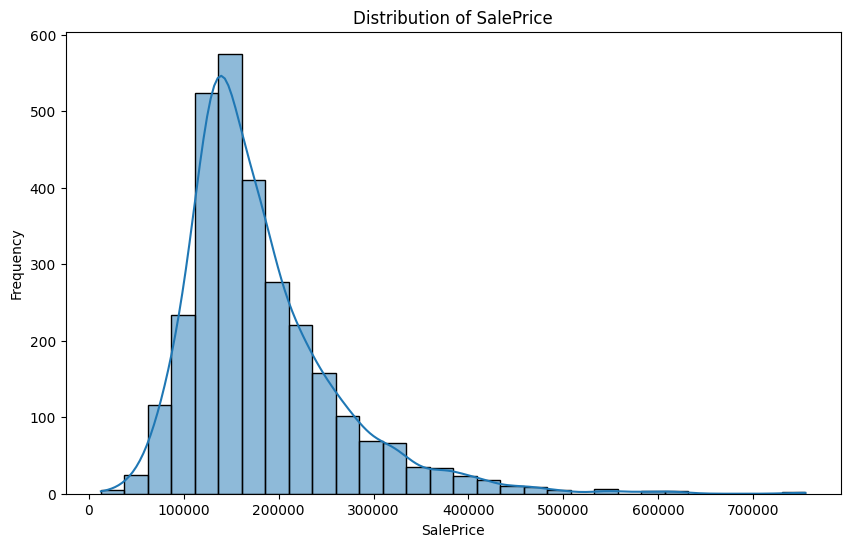

In [ ]:
# Step 3: Univariate Analysis
# ---------------------------
# Analyzing a Numerical Feature
univariate_analyzer = UnivariateAnalyzer(NumericalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, "SalePrice")

c:\Users\Suprit_Raj\OneDrive\Desktop\ML\prices-predictor-system\prices-predictor-system\analysis\analyze_src\univariate_analysis.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=feature, data=df, palette="muted")


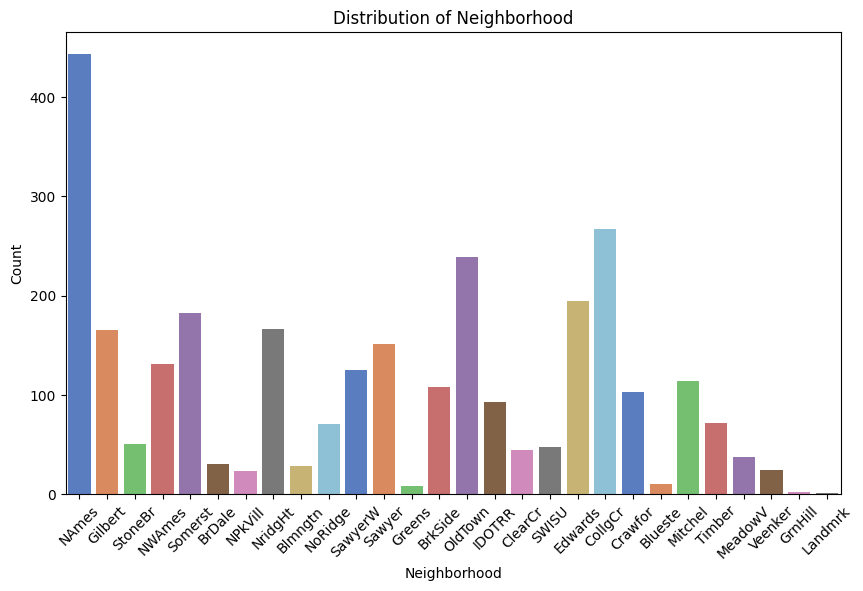

In [ ]:
# Analyzing a Categorical Feature
univariate_analyzer.set_strategy(CategoricalUnivariateAnalysis())
univariate_analyzer.execute_analysis(df, "Neighborhood")

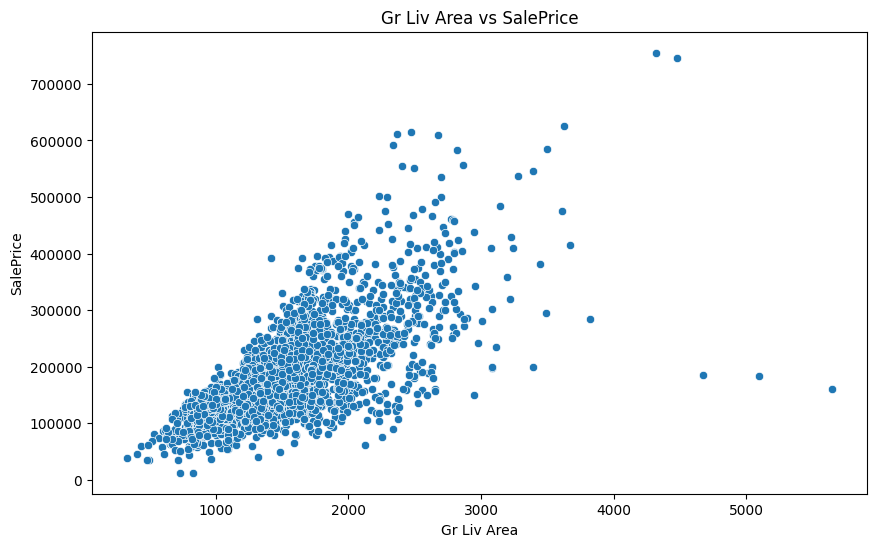

In [ ]:
# Step 4: Bivariate Analysis
# --------------------------
# Analyzing the Relationship between Two Numerical Features
bivariate_analyzer = BivariateAnalyzer(NumericalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df, "Gr Liv Area", "SalePrice")

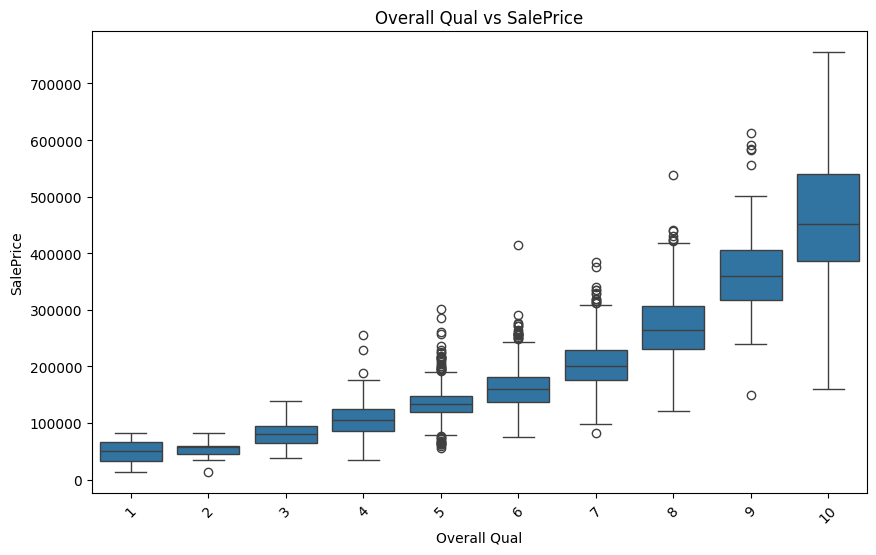

In [ ]:
# Analyzing the Relationship Between a Categorical and a Numerical Feature
bivariate_analyzer.set_strategy(CategoricalVsNumericalAnalysis())
bivariate_analyzer.execute_analysis(df, "Overall Qual", "SalePrice")

## Insights from Univariate and Bivariate Analysis

## Step 3: Univariate Analysis

  1. SalePrice Distribution (Numerical Feature):
       * Insight: The distribution of SalePrice is positively skewed, with the majority of house prices falling between $100,000 and $250,000. The peak frequency is around the $200,000 mark.

       * Implication: This skewness suggests that most homes in the dataset are relatively affordable, with fewer high-end properties. The long tail on the right side indicates a small number of more expensive homes, which may need special consideration during modelling (e.g., applying a log transformation to normalize the distribution).

  2. Neighborhood Distribution (Categorical Feature):
       * Insight: The Neighborhood feature shows a varied distribution, with NAmes being the most common neighborhood, followed by CoogCr and OldTown. Some neighborhoods have very few observations.

       * Implication: The high frequency of certain neighborhoods suggests that these areas could significantly influence overall housing prices. Neighborhoods with fewer observations might require careful handling to avoid overfitting during model training, potentially using techniques like frequency encoding or grouping similar neighborhoods together.


## Step 4: Bivariate Analysis
   1. Gr Liv Area vs. SalePrice (Numerical vs. Numerical):
      * Insight: There is strong positive correlation between Gr Liv Area (Above Ground Living Area) and SalePrice, indicating that larger homes generally sell for higher prices. The relationship appears mostly linear, but there are a few outliers, especially at higher Gr Liv Area values.
      * Implication: This linear relationship confirms that Gr Liv Area is likely a strong predictor of SalePrice. However, the presence of outliers (large homes with lower than expected prices) might require further investigation to determine whether they should be treated or removed.

   2. Overall Qual vs. SalePrice (Categorical vs. Numerical):
       * Insight: There is clear positive relation between Overall Qual (Overall Quality) and SalePrice, with higher quality ratings associated with significantly higher prices. The box plot shows increaing medians and ranges as quality improves, with some variability in each category.
       * Implication: Overall Qual is another strong predictor of SalePrice. The consistent increase in sale price with higher quality ratings suggests that homebuyers highly value quality. The variability within each category might be due to other factors influencing price, such as location or specific features not captured by Overall Qual


## Summary:

  * Key Predictors: Both Gr Liv Area and Overall Qual are strong predictors of SalePrice. These features should be emphasized in any predictive models.
  * Data Distribution: The positive skew in SalePrice and the wide range of values for both Gr Liv Area and Overall Qual indicate the need for careful data preprocessing, including potential normalization or transformation of features.
  * Outliers: Outliers in the relationshiop between Gr Liv Area and SalePrice need to be examined closely, as they may represent special cases (e.g., luxary homes) that could skew the model if not properly addressed.


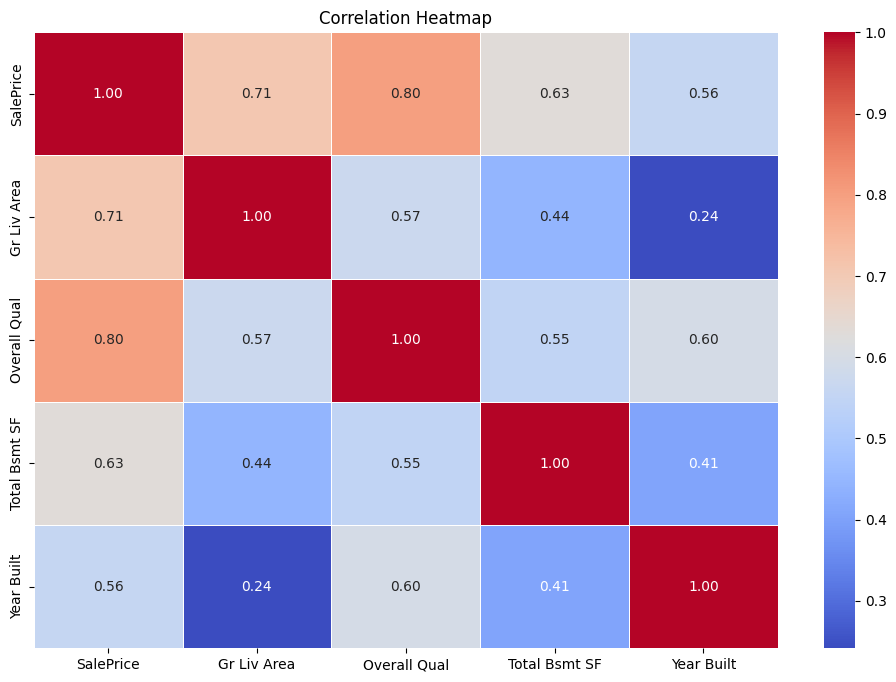

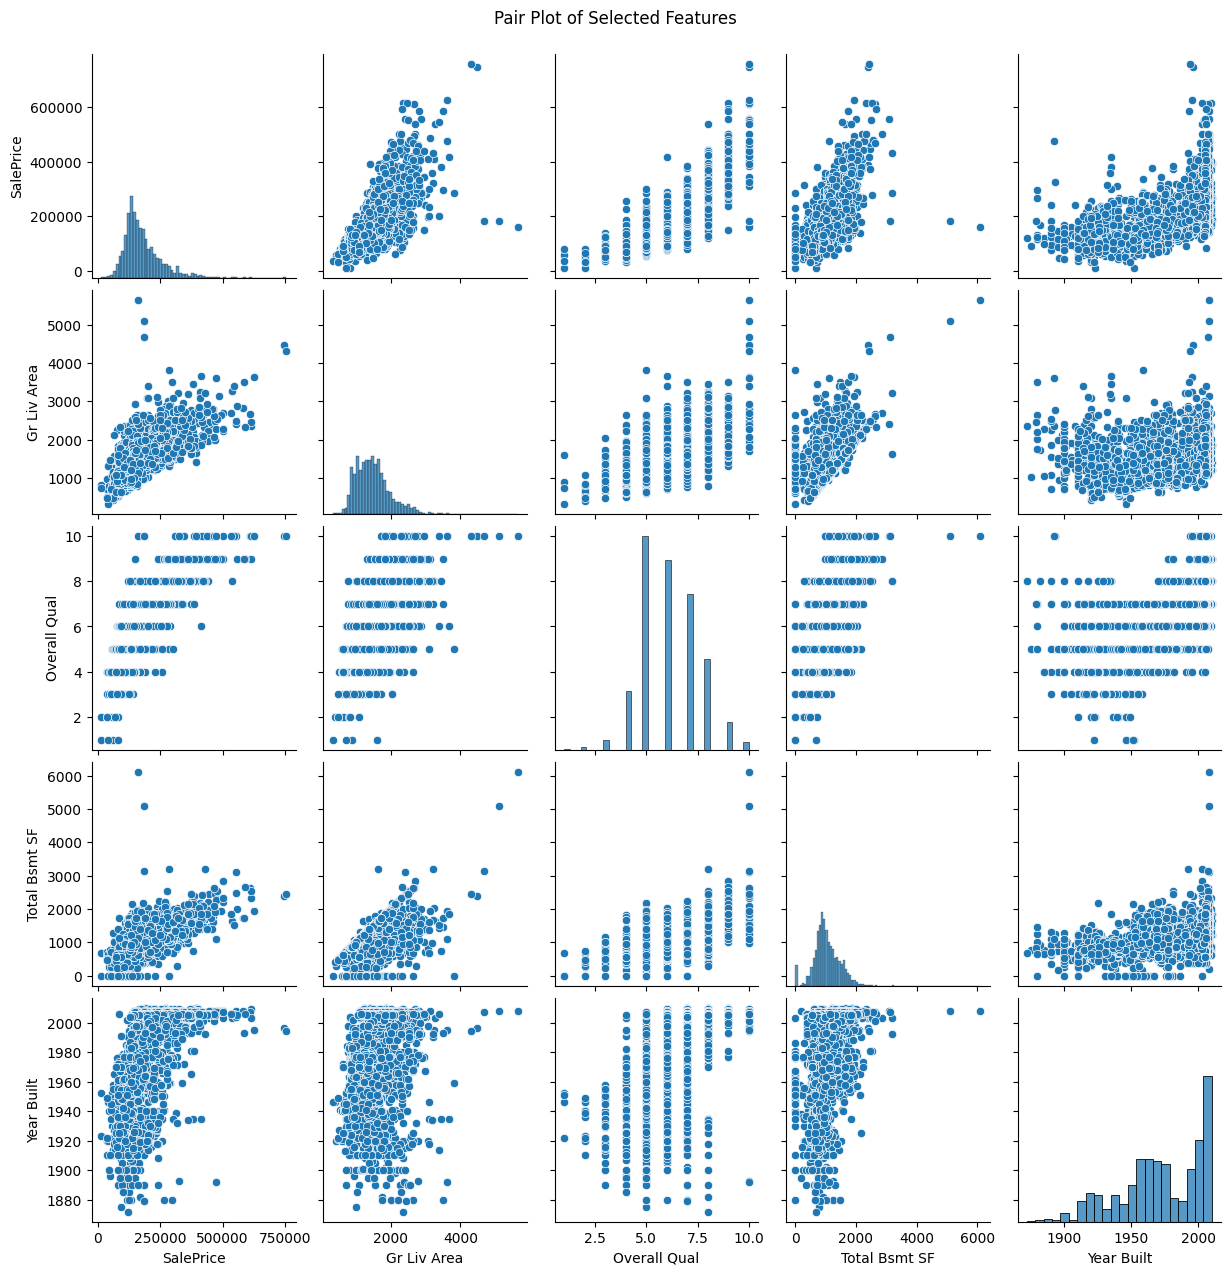

In [ ]:
# Step 5: Multivariate Analysis
# -----------------------------
# Perform Multivariate Analysis

# Initialize the MultivariateAnalyzer with the SimpleMultivariateAnalysis strategy
multivariate_analyzer = SimpleMultivariateAnalysis()

# Select important features for the analysis
selected_features = df[['SalePrice', 'Gr Liv Area', 'Overall Qual', 'Total Bsmt SF', 'Year Built']]

# Execute the multivariate analysis
multivariate_analyzer.analyze(selected_features)

## Insights from Multivariate Analysis

## Correlation Heatmap:

   1. SalePrice and Overall Qual:
      * Insight: The highest correlation observed is between SalePrice and Overall Qual (0.80). This strong positive correlation indicates that the overall quality of the house is a significant determinant of its price.
      * Implication: Overall Qual should be considered a key predictor in the model. The high correlation suggests that this feature explains a substantial portion of the variance in house prices.

    2. SalePrice and Gr Liv Area:
      * Insight: The correlation between SalePrice and Gr Liv Area (0.71) is also strong, indicating that larger homes generally have higher sale prices.
      * Implication: Similar to Overall Qual, Gr Liv Area is another critical predictor of SalePrice. The relationship aligns with the expectation that more living space increase a property's value.

    3. Total Bsmt SF:
      * Insight: The correlation between Total Bsmt SF and SalePrice (0.63) is moderate, suggesting that the size of the basement contributes to the overall value but not as strongly as living area or quality.
      * Implication: Total Bsmt SF is an important feature, but it may require further exploration or interaction with other features to capture its full effect.

    4. Year Built:
       * Insight: Year Built has a lower correlation with SalePrice (0.56). While newer homes tend to sell for more, this relationship is less pronounced than those with living area or quality.
       * Implication: The age of the house is a relevant factor but might be more meaningful when combined with other features lik Overall Qual or Remod/ Add Year.


## Pair Plot:

   1. Linear Relationships:
      * Insight: The pair plots confirm linear relationships  between SalePrice and both Gr Liv Area and Total Bsmt SF, supporting their inclusion as linear predictors in the model.
      * Implication: These linear relationships suggest that linear models (or transformations) could effectively capture these predictors' contributions to SalePrice.

    2. Discrete Distribution of Overall Qual:
       * Insight: Overall Qual appears as a discrete variable in the pair plots, with significant gaps between categories. This suggests that it is more ordinal in nature.
       * Implication: Given its ordinal nature, Overall Qual might be better treated as a categorical variable with ordered categories. This could improve the interpretability and performance of the model.
    3. Potential Multicollinearity:
       * Insight: The strong correlations between Gr Liv Area, Overall Qual, and Total Bsmt SF suggest potential multicollinearity, which could inflate variance in model coefficients.
       * Implication: Multicollinearity should be checked using Variance Inflation Factor(VIF) analysis. If multicollinearity is confirmed, techniques like feature selection, regularization, or Principal Component Analysis(PCA) mightt be needed.

## Issues to Address:

1. Multicollinearity:
    * Issue: The high correlations between key predictors could lead to multicollinearity in regression models, which could skew the results and reduce model interpretability.
    * Action: Conduct VIF analysis to check for multicollinearity. If detected, consider removing or combining correlated features, using regularization techniques, or applying PCA to reduce dimensionality.

2. Feature Engineering:
    * Issue: Features like Overall Qual, which is ordinal, might benefit from specific treatment (e.g., encoding as an ordinal variable) rather being treated as continuous.
    * Action: Consider encoding Overall Qual as an ordinal variable. Also, explore interactions between features like Gr Liv Area and Total Bsmt SF to capture more complex relationships.

3. Outliers:
    * Issue: The pair plots indicate potential outliers, especially in Gr Liv Area and SalePrice. These could be high-leverage points that unduly influence model performance.
    * Action: Identify and analyze outliers to determine if they should be removed or if the model should be adjusted to account for them (e.g., using robust regression techniques).